# Train predictor — data splits

Loads `data/training_data.csv` and splits it **80% / 10% / 10%** into train, validation, and test sets (same random seed as `train_nn.py` for reproducibility).

In [1]:
import os

import pandas as pd
from sklearn.model_selection import train_test_split

RANDOM_SEED = 42

project_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
DATA_CSV = os.path.join(project_dir, "data", "training_data.csv")

df = pd.read_csv(DATA_CSV)
print(f"Loaded {len(df)} rows from {DATA_CSV}")
df.head()

Loaded 500 rows from /Users/alexismarez/Downloads/GreenByte/data/training_data.csv


,sim_id,simulation_days,start_day,start_month,in_tSpDay,in_tSpNight,in_thetaLampMax,in_heatDeadZone,in_rhMax,out_yield_kg_m2,...,out_mean_tAir_C,out_min_tAir_C,out_mean_rh_pct,out_mean_tCan_C,out_final_cFruit,out_cost_heat_usd_m2,out_cost_light_usd_m2,out_cost_water_usd_m2,out_cost_total_usd_m2,out_cost_per_kg_yield
0,1,30,16,1,11.803547,11.803547,2.684719,19.890149,93.213136,1.330055e-96,...,14.270612,6.895527,83.850289,14.770125,50182.589673,0.367219,0.034306,0.035509,0.437035,NaN
1,2,30,283,10,19.358216,12.605343,13.340600,17.725788,80.616025,1.250893e-84,...,17.993797,9.525302,79.881623,18.365106,79370.616078,0.339689,0.077921,0.051451,0.469061,NaN
2,0,30,254,9,18.758271,15.861095,32.162523,15.867112,81.588731,9.400207e-91,...,25.002861,15.173431,71.954947,25.359609,64018.869150,0.042186,0.125235,0.063194,0.230616,NaN
3,7,30,237,8,18.256587,18.256587,19.865032,10.999801,76.302435,2.673359e-84,...,25.118147,16.500000,60.008996,25.480167,80534.057449,0.061482,0.117718,0.078089,0.257289,NaN
4,6,30,327,11,18.415371,15.827839,25.151083,10.894063,76.964969,3.878562e-79,...,16.180775,8.913812,80.615720,15.910613,92548.228129,0.712330,1.075662,0.049654,1.837646,NaN


In [2]:
# 80% train, 20% holdout — then split holdout 50/50 → 10% val, 10% test
train_df, temp_df = train_test_split(
    df,
    test_size=0.2,
    random_state=RANDOM_SEED,
    shuffle=True,
)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=RANDOM_SEED,
    shuffle=True,
)

n = len(df)
print(
    f"train: {len(train_df)} ({len(train_df)/n:.0%}), "
    f"val: {len(val_df)} ({len(val_df)/n:.0%}), "
    f"test: {len(test_df)} ({len(test_df)/n:.0%})"
)

train: 400 (80%), val: 50 (10%), test: 50 (10%)


In [3]:
# ╔════════════════════════════════════════════════════════════════════════════╗
# ║  OPTIONAL: training-data refinement / augmentation (train split only)      ║
# ╚════════════════════════════════════════════════════════════════════════════╝
# Goal: improve generalization/accuracy WITHOUT leaking info from val/test.
#
# Notes on bootstrapping here:
# - Pure bootstrap (resampling with replacement) does NOT add new information.
# - It can still help optimization (like reweighting) and stability.
# - Adding small input jitter (noise injection) can act like regularization.
# - If you need *real* new information, you must run more simulations.

import numpy as np

# ---------------- CHANGE HERE ----------------
DO_DROP_TRAIN_OUTLIERS = False
OUTLIER_METHOD = "iqr"   # "iqr" or "zscore"
OUTLIER_STRENGTH = 3.0   # z-score threshold OR IQR multiplier (typical: 1.5 to 3.0)

DO_BOOTSTRAP_AUGMENT = False
BOOTSTRAP_MULTIPLIER = 3  # 1 = no extra data, 3 = add ~2x more rows

# Jitter only applies to *input* columns. Targets stay paired with sampled row.
# Keep these small so you don't create physically unrealistic points.
JITTER_STD_FRACTION = {
    # std as fraction of each column's range
    "in_tSpDay": 0.01,
    "in_tSpNight": 0.01,
    "in_thetaLampMax": 0.02,
    "in_heatDeadZone": 0.02,
    "in_rhMax": 0.01,
}
# ------------------------------------------------


def _drop_outliers_train_only(d: pd.DataFrame, target_cols: list[str]) -> pd.DataFrame:
    d = d.copy()
    y = d[target_cols].replace([np.inf, -np.inf], np.nan)
    mask = y.notna().all(axis=1)
    d = d.loc[mask].reset_index(drop=True)
    y = y.loc[mask]

    if OUTLIER_METHOD == "zscore":
        mu = y.mean(axis=0)
        sigma = y.std(axis=0).replace(0, np.nan)
        z = (y - mu) / sigma
        keep = z.abs().le(OUTLIER_STRENGTH).all(axis=1)
    elif OUTLIER_METHOD == "iqr":
        q1 = y.quantile(0.25)
        q3 = y.quantile(0.75)
        iqr = (q3 - q1).replace(0, np.nan)
        lo = q1 - OUTLIER_STRENGTH * iqr
        hi = q3 + OUTLIER_STRENGTH * iqr
        keep = ((y >= lo) & (y <= hi)).all(axis=1)
    else:
        raise ValueError(f"Unknown OUTLIER_METHOD: {OUTLIER_METHOD}")

    dropped = (~keep).sum()
    print(f"[train refine] Dropped {int(dropped)} outlier rows (method={OUTLIER_METHOD}).")
    return d.loc[keep].reset_index(drop=True)


def _bootstrap_augment_train_only(
    d: pd.DataFrame,
    input_cols: list[str],
    seed: int,
) -> pd.DataFrame:
    """Bootstrap resample rows + add small jitter to inputs. Train split only."""
    rng = np.random.default_rng(seed)

    n = len(d)
    if BOOTSTRAP_MULTIPLIER <= 1:
        return d

    idx = rng.integers(0, n, size=n * (BOOTSTRAP_MULTIPLIER - 1))
    extra = d.iloc[idx].copy().reset_index(drop=True)

    # Column-wise jitter based on observed train ranges
    for col in input_cols:
        if col not in extra.columns:
            continue
        frac = JITTER_STD_FRACTION.get(col, 0.0)
        if frac <= 0:
            continue
        col_min = float(d[col].min())
        col_max = float(d[col].max())
        span = col_max - col_min
        if span <= 0:
            continue
        noise = rng.normal(loc=0.0, scale=frac * span, size=len(extra))
        extra[col] = extra[col].astype(float) + noise
        extra[col] = extra[col].clip(lower=col_min, upper=col_max)

    # Enforce known constraint from sweep: night setpoint ≤ day setpoint
    if "in_tSpNight" in extra.columns and "in_tSpDay" in extra.columns:
        extra["in_tSpNight"] = np.minimum(extra["in_tSpNight"], extra["in_tSpDay"]).astype(float)

    out = pd.concat([d.reset_index(drop=True), extra], axis=0).reset_index(drop=True)
    print(f"[train augment] Bootstrapped train rows: {len(d)} → {len(out)}")
    return out


# Apply (train only)
if DO_DROP_TRAIN_OUTLIERS:
    train_df = _drop_outliers_train_only(train_df, TARGET_COLS)

if DO_BOOTSTRAP_AUGMENT:
    # Uses the raw CSV column names (not engineered features)
    raw_input_cols = [
        "in_tSpDay",
        "in_tSpNight",
        "in_thetaLampMax",
        "in_heatDeadZone",
        "in_rhMax",
    ]
    train_df = _bootstrap_augment_train_only(train_df, raw_input_cols, seed=RANDOM_SEED)

## K-fold cross-validation (5-fold on 90% dev set)

We keep the existing **10% test holdout** untouched and run **5-fold CV** on the remaining 90% (`train_df` + `val_df`) to estimate generalization and select hyperparameters by mean `val_mse_scaled`.

In [4]:
from dataclasses import dataclass

import numpy as np
import pandas as pd
from sklearn.model_selection import KFold


@dataclass(frozen=True)
class TrainConfig:
    hidden_sizes: tuple[int, ...]
    dropout_p: float
    optimizer: str
    learning_rate: float
    weight_decay: float
    batch_size: int
    max_epochs: int
    early_stopping: bool = True
    patience: int = 60
    min_delta: float = 0.0


def train_one_fold(cfg: TrainConfig, df_tr: pd.DataFrame, df_va: pd.DataFrame, *, seed: int) -> dict:
    """Train one fold; returns best val_mse_scaled + per-target metrics (report units)."""
    import torch
    from torch import nn
    from torch.utils.data import DataLoader, TensorDataset

    fold = prepare_fold_data(df_tr, df_va)

    X_train = fold["X_train"]
    y_train = fold["y_train"]
    X_val = fold["X_val"]
    y_val = fold["y_val"]

    # Tensors
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    torch.manual_seed(seed)
    np.random.seed(seed)

    X_train_t = torch.tensor(X_train, dtype=torch.float32, device=device)
    y_train_t = torch.tensor(y_train, dtype=torch.float32, device=device)
    X_val_t = torch.tensor(X_val, dtype=torch.float32, device=device)
    y_val_t = torch.tensor(y_val, dtype=torch.float32, device=device)

    loader = DataLoader(
        TensorDataset(X_train_t, y_train_t),
        batch_size=cfg.batch_size,
        shuffle=True,
    )

    model = SurrogateMLP(
        n_in=X_train.shape[1],
        n_out=y_train.shape[1],
        hidden=cfg.hidden_sizes,
        dropout_p=cfg.dropout_p,
    ).to(device)

    # Optimizer
    opt_name = cfg.optimizer.lower()
    if opt_name == "adamw":
        optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.learning_rate, weight_decay=cfg.weight_decay)
    elif opt_name == "adam":
        optimizer = torch.optim.Adam(model.parameters(), lr=cfg.learning_rate, weight_decay=cfg.weight_decay)
    elif opt_name == "sgd":
        optimizer = torch.optim.SGD(
            model.parameters(),
            lr=cfg.learning_rate,
            momentum=0.9,
            weight_decay=cfg.weight_decay,
            nesterov=True,
        )
    else:
        raise ValueError(f"Unknown optimizer: {cfg.optimizer}")

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=20, min_lr=1e-6
    )

    loss_fn = nn.MSELoss()

    def mse_scaled(X_t, y_t) -> float:
        model.eval()
        with torch.no_grad():
            pred = model(X_t)
            return float(loss_fn(pred, y_t).cpu())

    best_val = float("inf")
    best_epoch = 0
    best_state = None
    no_improve = 0

    for epoch in range(1, cfg.max_epochs + 1):
        model.train()
        for xb, yb in loader:
            optimizer.zero_grad(set_to_none=True)
            pred = model(xb)
            loss = loss_fn(pred, yb)
            loss.backward()
            optimizer.step()

        val_mse = mse_scaled(X_val_t, y_val_t)
        scheduler.step(val_mse)

        if val_mse < (best_val - cfg.min_delta):
            best_val = float(val_mse)
            best_epoch = int(epoch)
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1

        if cfg.early_stopping and no_improve >= cfg.patience:
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    # Predict in scaled space then map to report units
    model.eval()
    with torch.no_grad():
        val_pred_scaled = model(X_val_t).detach().cpu().numpy()

    val_pred_report = fold["to_report_units"](val_pred_scaled, is_scaled=True)

    # Optional RH clipping (plausibility)
    if "out_mean_rh_pct" in TARGET_COLS:
        rh_i = TARGET_COLS.index("out_mean_rh_pct")
        val_pred_report[:, rh_i] = np.clip(val_pred_report[:, rh_i], 0.0, 100.0)

    metrics = metrics_per_target(fold["y_val_raw"], val_pred_report)

    return {
        "best_val_mse_scaled": best_val,
        "best_epoch": best_epoch,
        "val_metrics": metrics,
        "model_state": best_state,
        "fold": fold,
    }


def run_kfold_cv(
    *,
    df_dev: pd.DataFrame,
    cfg: TrainConfig,
    n_splits: int = 5,
    seed: int = 42,
) -> dict:
    """Runs K-fold CV on df_dev and returns summaries.

    Expects prepare_fold_data(), SurrogateMLP, and metrics_per_target() to be defined
    (they are defined later in the notebook).
    """
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)

    fold_rows = []
    fold_metrics = []
    best_epochs = []

    for fold_idx, (tr_idx, va_idx) in enumerate(kf.split(df_dev), start=1):
        df_tr = df_dev.iloc[tr_idx].reset_index(drop=True)
        df_va = df_dev.iloc[va_idx].reset_index(drop=True)

        out = train_one_fold(cfg, df_tr, df_va, seed=seed + fold_idx)
        fold_rows.append({
            "fold": fold_idx,
            "best_val_mse_scaled": out["best_val_mse_scaled"],
            "best_epoch": out["best_epoch"],
        })
        best_epochs.append(out["best_epoch"])

        m = out["val_metrics"].copy()
        m["fold"] = fold_idx
        fold_metrics.append(m)

    cv_summary = pd.DataFrame(fold_rows)
    cv_metrics = pd.concat(fold_metrics, axis=0).reset_index(drop=True)
    mean_best_epoch = int(round(float(np.mean(best_epochs))))

    return {
        "cv_summary": cv_summary,
        "cv_metrics": cv_metrics,
        "mean_best_epoch": mean_best_epoch,
    }


# NOTE: This cell only defines CV helpers.
# Run CV after feature engineering + SurrogateMLP + metrics helpers are defined.

## Neural network predictor (starter shell)

Below is a **template** you can grow into a full trainer. Look for comment blocks marked **CHANGE HERE**.

**Dependency:** `pip install torch` (CPU build is fine for this dataset size).

Sections:
1. **CONFIG** — input columns, target columns, architecture, training hyperparameters  
2. **Features & scaling** — turn DataFrames into arrays (optional cyclical month)  
3. **Model** — PyTorch `Module` — layer sizes follow `HIDDEN_SIZES`  
4. **Train / evaluate** — optimizer, loss, loop — swap or extend as needed

In [5]:
# ╔════════════════════════════════════════════════════════════════════════════╗
# ║  CONFIG — edit column lists and hyperparameters here                       ║
# ╚════════════════════════════════════════════════════════════════════════════╝

# --- Inputs: must match column names in data/training_data.csv ---
RAW_INPUT_COLS = [
    "in_tSpDay",
    "in_tSpNight",
    "in_thetaLampMax",
    "in_heatDeadZone",
    "in_rhMax",
    "start_month",  # REMOVE from this list if you drop seasonal feature
]

# --- Targets: pick any subset of out_* columns from the CSV ---
TARGET_COLS = [
    "out_mean_tAir_C",
    "out_mean_rh_pct",
    "out_cost_total_usd_m2",
]

# Encode start_month as sin/cos (recommended). Set False to use numeric month only
# (then keep "start_month" in RAW_INPUT_COLS — one column).
USE_CYCLICAL_MONTH = True

# --- Architecture: hidden layer widths; change depth/width freely ---
# Smaller nets can generalize better on ~500 rows.
HIDDEN_SIZES = (128, 64, 32)  # try (64, 32)

# --- Training knobs ---
LEARNING_RATE = 1e-3
BATCH_SIZE = 32
N_EPOCHS = 1000
WEIGHT_DECAY = 3e-4  # try 1e-4 or 3e-4
DROPOUT_P = 0.05     # used inside SurrogateMLP; sweep 0.0/0.05 in CV

# --- Second seed for torch only (keep aligned with RANDOM_SEED or set independently) ---
TORCH_SEED = 42

In [6]:
import numpy as np
from sklearn.preprocessing import StandardScaler

# CHANGE HERE: enable to balance MSE across targets
SCALE_TARGETS = True

# CHANGE HERE: optional per-target transforms (applied BEFORE scaling)
# Supported: None, "log1p" (must stay >= -1), "identity"
TARGET_TRANSFORMS = {
    # "out_cost_total_usd_m2": "log1p",  # often helps if cost is skewed
    # "out_mean_rh_pct": "identity",
    # "out_mean_tAir_C": "identity",
}

# ╔════════════════════════════════════════════════════════════════════════════╗
# ║  FEATURE ENGINEERING — change engineer_features() if you add/remove inputs ║
# ╚════════════════════════════════════════════════════════════════════════════╝


def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    """Build design matrix X from one split (train / val / test)."""
    missing = [c for c in RAW_INPUT_COLS if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns in CSV: {missing}")

    X = df[RAW_INPUT_COLS].copy()
    if USE_CYCLICAL_MONTH and "start_month" in X.columns:
        m = X["start_month"]
        X["month_sin"] = np.sin(2 * np.pi * m / 12)
        X["month_cos"] = np.cos(2 * np.pi * m / 12)
        X = X.drop(columns=["start_month"])
    return X


def build_xy(train_df: pd.DataFrame, val_df: pd.DataFrame, test_df: pd.DataFrame):
    """Returns scaled numpy arrays + scalers (fit on train only)."""

    # NOTE: For K-fold CV we use prepare_fold_data() (below) to avoid leakage per fold.

    def _finite_targets(d: pd.DataFrame) -> pd.Series:
        return d[TARGET_COLS].replace([np.inf, -np.inf], np.nan).notna().all(axis=1)

    # Drop rows with invalid target values
    train_df = train_df.loc[_finite_targets(train_df)].reset_index(drop=True)
    val_df = val_df.loc[_finite_targets(val_df)].reset_index(drop=True)
    test_df = test_df.loc[_finite_targets(test_df)].reset_index(drop=True)

    missing_y = [c for c in TARGET_COLS if c not in train_df.columns]
    if missing_y:
        raise ValueError(f"Missing target columns: {missing_y}")

    X_train_df = engineer_features(train_df)
    X_val_df = engineer_features(val_df)
    X_test_df = engineer_features(test_df)

    # Raw targets (for reporting)
    y_train_raw = train_df[TARGET_COLS].values.astype(np.float64)
    y_val_raw = val_df[TARGET_COLS].values.astype(np.float64)
    y_test_raw = test_df[TARGET_COLS].values.astype(np.float64)

    # Apply optional transforms for training-space y
    transform_names = [TARGET_TRANSFORMS.get(c, "identity") for c in TARGET_COLS]

    def _apply_transform(y_np: np.ndarray) -> np.ndarray:
        y2 = y_np.copy()
        for j, tname in enumerate(transform_names):
            if tname in (None, "identity"):
                continue
            if tname == "log1p":
                # Requires y >= -1; clip to avoid invalid values
                y2[:, j] = np.log1p(np.clip(y2[:, j], -0.999999, None))
            else:
                raise ValueError(f"Unknown transform: {tname}")
        return y2

    def _invert_transform(y_np: np.ndarray) -> np.ndarray:
        y2 = y_np.copy()
        for j, tname in enumerate(transform_names):
            if tname in (None, "identity"):
                continue
            if tname == "log1p":
                y2[:, j] = np.expm1(y2[:, j])
            else:
                raise ValueError(f"Unknown transform: {tname}")
        return y2

    y_train_model_raw = _apply_transform(y_train_raw)
    y_val_model_raw = _apply_transform(y_val_raw)
    y_test_model_raw = _apply_transform(y_test_raw)

    # Input scaling
    scaler_X = StandardScaler()
    X_train = scaler_X.fit_transform(X_train_df)
    X_val = scaler_X.transform(X_val_df)
    X_test = scaler_X.transform(X_test_df)

    # Target scaling (fit on train only)
    scaler_y = None
    if SCALE_TARGETS:
        scaler_y = StandardScaler()
        y_train = scaler_y.fit_transform(y_train_model_raw)
        y_val = scaler_y.transform(y_val_model_raw)
        y_test = scaler_y.transform(y_test_model_raw)
    else:
        y_train, y_val, y_test = y_train_model_raw, y_val_model_raw, y_test_model_raw

    feature_names = list(X_train_df.columns)
    return (
        X_train,
        y_train,
        X_val,
        y_val,
        X_test,
        y_test,
        scaler_X,
        scaler_y,
        feature_names,
        y_train_raw,
        y_val_raw,
        y_test_raw,
        transform_names,
        _invert_transform,
    )


def prepare_fold_data(df_train: pd.DataFrame, df_val: pd.DataFrame):
    """Fold-safe data prep: fit scalers/transforms on df_train only.

    Returns scaled arrays for training + raw arrays for reporting.
    """

    def _finite_targets(d: pd.DataFrame) -> pd.Series:
        return d[TARGET_COLS].replace([np.inf, -np.inf], np.nan).notna().all(axis=1)

    df_train = df_train.loc[_finite_targets(df_train)].reset_index(drop=True)
    df_val = df_val.loc[_finite_targets(df_val)].reset_index(drop=True)

    X_train_df = engineer_features(df_train)
    X_val_df = engineer_features(df_val)

    y_train_raw = df_train[TARGET_COLS].values.astype(np.float64)
    y_val_raw = df_val[TARGET_COLS].values.astype(np.float64)

    transform_names = [TARGET_TRANSFORMS.get(c, "identity") for c in TARGET_COLS]

    def _apply_transform(y_np: np.ndarray) -> np.ndarray:
        y2 = y_np.copy()
        for j, tname in enumerate(transform_names):
            if tname in (None, "identity"):
                continue
            if tname == "log1p":
                y2[:, j] = np.log1p(np.clip(y2[:, j], -0.999999, None))
            else:
                raise ValueError(f"Unknown transform: {tname}")
        return y2

    def _invert_transform(y_np: np.ndarray) -> np.ndarray:
        y2 = y_np.copy()
        for j, tname in enumerate(transform_names):
            if tname in (None, "identity"):
                continue
            if tname == "log1p":
                y2[:, j] = np.expm1(y2[:, j])
            else:
                raise ValueError(f"Unknown transform: {tname}")
        return y2

    y_train_model_raw = _apply_transform(y_train_raw)
    y_val_model_raw = _apply_transform(y_val_raw)

    scaler_X = StandardScaler()
    X_train = scaler_X.fit_transform(X_train_df)
    X_val = scaler_X.transform(X_val_df)

    scaler_y = None
    if SCALE_TARGETS:
        scaler_y = StandardScaler()
        y_train = scaler_y.fit_transform(y_train_model_raw)
        y_val = scaler_y.transform(y_val_model_raw)
    else:
        y_train, y_val = y_train_model_raw, y_val_model_raw

    def to_report_units(y_scaled_or_model_raw: np.ndarray, is_scaled: bool = True) -> np.ndarray:
        y_model_raw = scaler_y.inverse_transform(y_scaled_or_model_raw) if (is_scaled and scaler_y is not None) else y_scaled_or_model_raw
        return _invert_transform(y_model_raw)

    return {
        "X_train": X_train,
        "y_train": y_train,
        "X_val": X_val,
        "y_val": y_val,
        "y_train_raw": y_train_raw,
        "y_val_raw": y_val_raw,
        "scaler_X": scaler_X,
        "scaler_y": scaler_y,
        "feature_names": list(X_train_df.columns),
        "transform_names": transform_names,
        "to_report_units": to_report_units,
    }

In [7]:
(
    X_train,
    y_train,
    X_val,
    y_val,
    X_test,
    y_test,
    scaler_X,
    scaler_y,
    FEATURE_NAMES,
    y_train_raw,
    y_val_raw,
    y_test_raw,
    transform_names,
    invert_transform_y,
) = build_xy(train_df, val_df, test_df)

n_features = X_train.shape[1]
n_targets = len(TARGET_COLS)
print(f"Features ({n_features}): {FEATURE_NAMES}")
print(f"Targets ({n_targets}): {TARGET_COLS}")
print("X:", X_train.shape, "y (used for loss):", y_train.shape)
print("Target scaling:", "ON" if scaler_y is not None else "OFF")
print("Target transforms:", dict(zip(TARGET_COLS, transform_names)))

Features (7): ['in_tSpDay', 'in_tSpNight', 'in_thetaLampMax', 'in_heatDeadZone', 'in_rhMax', 'month_sin', 'month_cos']
Targets (3): ['out_mean_tAir_C', 'out_mean_rh_pct', 'out_cost_total_usd_m2']
X: (400, 7) y (used for loss): (400, 3)
Target scaling: ON
Target transforms: {'out_mean_tAir_C': 'identity', 'out_mean_rh_pct': 'identity', 'out_cost_total_usd_m2': 'identity'}


## Run K-fold CV + (optional) hyperparameter sweep

This section runs CV on the 90% dev set and can sweep a small grid of hyperparameters to minimize mean `val_mse_scaled`.

In [8]:
def run_hp_sweep(df_dev: pd.DataFrame) -> dict:
    """Run a small CV hyperparameter sweep. Call this AFTER SurrogateMLP is defined."""

    base = TrainConfig(
        hidden_sizes=tuple(HIDDEN_SIZES),
        dropout_p=float(DROPOUT_P),
        optimizer=str(OPTIMIZER_NAME),
        learning_rate=float(LEARNING_RATE),
        weight_decay=float(WEIGHT_DECAY),
        batch_size=int(BATCH_SIZE),
        max_epochs=int(N_EPOCHS),
    )

    # Keep this small—each config does 5 folds.
    candidates: list[TrainConfig] = []
    for hidden in [tuple(HIDDEN_SIZES), (128, 64, 32)]:
        for wd in [1e-4, 3e-4, 1e-3]:
            for drop in [0.0, 0.05]:
                candidates.append(
                    TrainConfig(
                        hidden_sizes=hidden,
                        dropout_p=drop,
                        optimizer=str(OPTIMIZER_NAME),
                        learning_rate=float(LEARNING_RATE),
                        weight_decay=float(wd),
                        batch_size=int(BATCH_SIZE),
                        max_epochs=int(N_EPOCHS),
                    )
                )

    results = []
    best = None
    for i, cfg in enumerate(candidates, start=1):
        out = run_kfold_cv(df_dev=df_dev, cfg=cfg, n_splits=5, seed=RANDOM_SEED)
        mean_mse = float(out["cv_summary"]["best_val_mse_scaled"].mean())
        std_mse = float(out["cv_summary"]["best_val_mse_scaled"].std())
        row = {
            "i": i,
            "hidden": cfg.hidden_sizes,
            "dropout": cfg.dropout_p,
            "wd": cfg.weight_decay,
            "opt": cfg.optimizer,
            "lr": cfg.learning_rate,
            "mean_val_mse_scaled": mean_mse,
            "std": std_mse,
            "mean_best_epoch": out["mean_best_epoch"],
        }
        results.append(row)
        if best is None or mean_mse < best["mean_val_mse_scaled"]:
            best = row

    sweep_df = pd.DataFrame(results).sort_values("mean_val_mse_scaled")
    print("Hyperparam sweep results (sorted)")
    display(sweep_df.head(10))
    print("\nBest config (by mean val_mse_scaled):")
    print(best)
    return {"best": best, "sweep_df": sweep_df}


# NOTE: This cell defines the sweep helper only.
# Call run_hp_sweep(DF_DEV) later, after SurrogateMLP is defined.

In [9]:
from typing import Sequence

import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

# ╔════════════════════════════════════════════════════════════════════════════╗
# ║  PYTORCH SETUP — change device if you want MPS/CUDA explicitly             ║
# ╚════════════════════════════════════════════════════════════════════════════╝

torch.manual_seed(TORCH_SEED)
np.random.seed(RANDOM_SEED)

# CHANGE HERE: force "cuda", "mps", or "cpu"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

X_train_t = torch.tensor(X_train, dtype=torch.float32, device=DEVICE)
y_train_t = torch.tensor(y_train, dtype=torch.float32, device=DEVICE)
X_val_t = torch.tensor(X_val, dtype=torch.float32, device=DEVICE)
y_val_t = torch.tensor(y_val, dtype=torch.float32, device=DEVICE)
X_test_t = torch.tensor(X_test, dtype=torch.float32, device=DEVICE)
y_test_t = torch.tensor(y_test, dtype=torch.float32, device=DEVICE)

train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=BATCH_SIZE,
    shuffle=True,
)


class SurrogateMLP(nn.Module):
    """CHANGE HERE: edit forward pass, activation, dropout, layers."""

    def __init__(self, n_in: int, n_out: int, hidden: Sequence[int], dropout_p: float = 0.0):
        super().__init__()
        layers_list = []
        prev = n_in
        for h in hidden:
            block = [
                nn.Linear(prev, h),
                nn.LayerNorm(h),
                nn.GELU(),
            ]
            if dropout_p and dropout_p > 0:
                block.append(nn.Dropout(p=float(dropout_p)))
            layers_list.extend(block)
            prev = h
        layers_list.append(nn.Linear(prev, n_out))
        self.net = nn.Sequential(*layers_list)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


model = SurrogateMLP(n_features, n_targets, HIDDEN_SIZES, dropout_p=DROPOUT_P).to(DEVICE)

# ╔════════════════════════════════════════════════════════════════════════════╗
# ║  Optimizer playground (CHANGE HERE)                                        ║
# ╚════════════════════════════════════════════════════════════════════════════╝

OPTIMIZER_NAME = "sgd"  # "adamw", "adam", "sgd", "rmsprop"

if OPTIMIZER_NAME == "adamw":
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
elif OPTIMIZER_NAME == "adam":
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
elif OPTIMIZER_NAME == "sgd":
    optimizer = torch.optim.SGD(model.parameters(), lr=LEARNING_RATE, momentum=0.9, weight_decay=WEIGHT_DECAY, nesterov=True)
elif OPTIMIZER_NAME == "rmsprop":
    optimizer = torch.optim.RMSprop(model.parameters(), lr=LEARNING_RATE, momentum=0.9, weight_decay=WEIGHT_DECAY)
else:
    raise ValueError(f"Unknown OPTIMIZER_NAME: {OPTIMIZER_NAME}")

# Optional scheduler (helps convergence)
USE_LR_SCHEDULER = True
scheduler = None
if USE_LR_SCHEDULER:
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=20, min_lr=1e-6
    )

# Loss is MSE in the (possibly scaled) y-space
loss_fn = nn.MSELoss()


def predict_np_scaled(X_t: torch.Tensor) -> np.ndarray:
    """Model output in the same space it was trained (scaled if SCALE_TARGETS=True)."""
    model.eval()
    with torch.no_grad():
        return model(X_t).detach().cpu().numpy()


def inverse_scale_y_to_model_raw(y_scaled: np.ndarray) -> np.ndarray:
    """Undo scaler_y only (returns y in transformed-raw space if transforms enabled)."""
    if scaler_y is None:
        return y_scaled
    return scaler_y.inverse_transform(y_scaled)


def to_report_units(y_model_raw: np.ndarray) -> np.ndarray:
    """Undo optional per-target transforms to get back to original CSV units."""
    return invert_transform_y(y_model_raw)


def metrics_per_target(y_true_raw_np: np.ndarray, y_pred_raw_np: np.ndarray) -> pd.DataFrame:
    """MAE/R² per target in original units."""
    from sklearn.metrics import mean_absolute_error, r2_score

    rows = []
    for i, name in enumerate(TARGET_COLS):
        yt = y_true_raw_np[:, i]
        yp = y_pred_raw_np[:, i]
        rows.append(
            {
                "target": name,
                "mae": float(mean_absolute_error(yt, yp)),
                "r2": float(r2_score(yt, yp)),
            }
        )
    return pd.DataFrame(rows)


def mse_scalar_scaled(X_t: torch.Tensor, y_t: torch.Tensor) -> float:
    """Scalar MSE in training space (scaled if SCALE_TARGETS=True)."""
    model.eval()
    with torch.no_grad():
        pred = model(X_t)
        return float(loss_fn(pred, y_t).cpu())


def mse_scalar_raw(y_true_raw_np: np.ndarray, y_pred_raw_np: np.ndarray) -> float:
    """Scalar MSE in original units (mixed-unit number; interpret cautiously)."""
    return float(np.mean((y_pred_raw_np - y_true_raw_np) ** 2))


Device: cpu


In [10]:
# ╔════════════════════════════════════════════════════════════════════════════╗
# ║  TRAINING LOOP — early stopping on val_mse_scaled (best checkpoint)        ║
# ╚════════════════════════════════════════════════════════════════════════════╝

EARLY_STOPPING = True
ES_PATIENCE = 60
ES_MIN_DELTA = 0.0

train_mse_hist = []
val_mse_hist = []
lr_hist = []

best_val = float("inf")
best_epoch = 0
best_state = None
no_improve = 0

for epoch in range(1, N_EPOCHS + 1):
    model.train()
    for xb, yb in train_loader:
        optimizer.zero_grad(set_to_none=True)
        pred = model(xb)
        loss = loss_fn(pred, yb)
        loss.backward()
        optimizer.step()

    train_mse = mse_scalar_scaled(X_train_t, y_train_t)
    val_mse = mse_scalar_scaled(X_val_t, y_val_t)
    train_mse_hist.append(train_mse)
    val_mse_hist.append(val_mse)
    lr_hist.append(float(optimizer.param_groups[0]["lr"]))

    if scheduler is not None:
        scheduler.step(val_mse)

    # Track best checkpoint
    if val_mse < (best_val - ES_MIN_DELTA):
        best_val = float(val_mse)
        best_epoch = int(epoch)
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        no_improve = 0
    else:
        no_improve += 1

    if epoch == 1 or epoch % max(1, N_EPOCHS // 10) == 0:
        print(
            f"epoch {epoch:>4}  train_mse_scaled={train_mse:.6f}  val_mse_scaled={val_mse:.6f}  best={best_val:.6f}@{best_epoch}  lr={lr_hist[-1]:.2e}"
        )

    if EARLY_STOPPING and no_improve >= ES_PATIENCE:
        print(f"Early stopping at epoch {epoch} (best val {best_val:.6f} at epoch {best_epoch}).")
        break

# Restore best weights
if best_state is not None:
    model.load_state_dict(best_state)

print(f"\nBest epoch: {best_epoch}")
print(f"Min val_mse_scaled: {best_val:.6f}")

# Predictions in report units
train_pred_report = to_report_units(inverse_scale_y_to_model_raw(predict_np_scaled(X_train_t)))
val_pred_report = to_report_units(inverse_scale_y_to_model_raw(predict_np_scaled(X_val_t)))
test_pred_report = to_report_units(inverse_scale_y_to_model_raw(predict_np_scaled(X_test_t)))

# RH clipping check (and optional clipping for plausibility)
CLIP_RH = True
if "out_mean_rh_pct" in TARGET_COLS:
    rh_i = TARGET_COLS.index("out_mean_rh_pct")
    frac_oob = float(((test_pred_report[:, rh_i] < 0) | (test_pred_report[:, rh_i] > 100)).mean())
    print(f"RH out-of-range fraction (test): {frac_oob:.3%}")
    if CLIP_RH:
        test_pred_report[:, rh_i] = np.clip(test_pred_report[:, rh_i], 0.0, 100.0)
        val_pred_report[:, rh_i] = np.clip(val_pred_report[:, rh_i], 0.0, 100.0)
        train_pred_report[:, rh_i] = np.clip(train_pred_report[:, rh_i], 0.0, 100.0)

print("\nTrain per-target metrics")
display(metrics_per_target(y_train_raw, train_pred_report))
print("\nVal per-target metrics")
display(metrics_per_target(y_val_raw, val_pred_report))
print("\nTest per-target metrics")
display(metrics_per_target(y_test_raw, test_pred_report))

print(f"\nTest MSE (scaled training space): {mse_scalar_scaled(X_test_t, y_test_t):.6f}")
print(f"Test MSE (original units; mixed targets): {mse_scalar_raw(y_test_raw, test_pred_report):.6f}")

epoch    1  train_mse_scaled=0.723281  val_mse_scaled=0.761184  best=0.761184@1  lr=1.00e-03
epoch  100  train_mse_scaled=0.049493  val_mse_scaled=0.060258  best=0.059519@95  lr=1.00e-03
epoch  200  train_mse_scaled=0.035305  val_mse_scaled=0.052187  best=0.051114@150  lr=2.50e-04
Early stopping at epoch 210 (best val 0.051114 at epoch 150).

Best epoch: 150
Min val_mse_scaled: 0.051114
RH out-of-range fraction (test): 0.000%

Train per-target metrics


,target,mae,r2
0,out_mean_tAir_C,0.689149,0.973623
1,out_mean_rh_pct,2.018750,0.951462
2,out_cost_total_usd_m2,0.058642,0.956002



Val per-target metrics


,target,mae,r2
0,out_mean_tAir_C,0.909302,0.959129
1,out_mean_rh_pct,2.404844,0.947333
2,out_cost_total_usd_m2,0.060862,0.954238



Test per-target metrics


,target,mae,r2
0,out_mean_tAir_C,0.863205,0.960513
1,out_mean_rh_pct,2.324342,0.929548
2,out_cost_total_usd_m2,0.078497,0.877656



Test MSE (scaled training space): 0.060036
Test MSE (original units; mixed targets): 3.833450


In [11]:
# Actually run CV + sweep now that model + helpers exist
DF_DEV = pd.concat([train_df, val_df], axis=0).reset_index(drop=True)

SWEEP_OUT = run_hp_sweep(DF_DEV)
BEST_CFG = SWEEP_OUT["best"]
MEAN_BEST_EPOCH = int(BEST_CFG["mean_best_epoch"])

Hyperparam sweep results (sorted)


,i,hidden,dropout,wd,opt,lr,mean_val_mse_scaled,std,mean_best_epoch
5,6,"(128, 64, 32)",0.05,0.0010,sgd,0.001,0.087389,0.018647,160
11,12,"(128, 64, 32)",0.05,0.0010,sgd,0.001,0.087389,0.018647,160
3,4,"(128, 64, 32)",0.05,0.0003,sgd,0.001,0.087431,0.018561,167
9,10,"(128, 64, 32)",0.05,0.0003,sgd,0.001,0.087431,0.018561,167
1,2,"(128, 64, 32)",0.05,0.0001,sgd,0.001,0.087441,0.018528,167
7,8,"(128, 64, 32)",0.05,0.0001,sgd,0.001,0.087441,0.018528,167
4,5,"(128, 64, 32)",0.00,0.0010,sgd,0.001,0.101939,0.019330,94
10,11,"(128, 64, 32)",0.00,0.0010,sgd,0.001,0.101939,0.019330,94
2,3,"(128, 64, 32)",0.00,0.0003,sgd,0.001,0.102049,0.019277,94
8,9,"(128, 64, 32)",0.00,0.0003,sgd,0.001,0.102049,0.019277,94



Best config (by mean val_mse_scaled):
{'i': 6, 'hidden': (128, 64, 32), 'dropout': 0.05, 'wd': 0.001, 'opt': 'sgd', 'lr': 0.001, 'mean_val_mse_scaled': 0.08738878220319748, 'std': 0.01864658226908238, 'mean_best_epoch': 160}


## Final training on 90% dev set, evaluate once on 10% test holdout

We train using the best CV-selected hyperparameters and `MEAN_BEST_EPOCH` (from CV) on the full dev set, then evaluate exactly once on `test_df`.

In [12]:
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

# Build train/test arrays with scalers fit on full dev set
fold_final = prepare_fold_data(DF_DEV, test_df)

X_tr = fold_final["X_train"]
y_tr = fold_final["y_train"]
X_te = fold_final["X_val"]
y_te = fold_final["y_val"]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(TORCH_SEED)
np.random.seed(RANDOM_SEED)

X_tr_t = torch.tensor(X_tr, dtype=torch.float32, device=device)
y_tr_t = torch.tensor(y_tr, dtype=torch.float32, device=device)
X_te_t = torch.tensor(X_te, dtype=torch.float32, device=device)
y_te_t = torch.tensor(y_te, dtype=torch.float32, device=device)

loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=int(BATCH_SIZE), shuffle=True)

model_final = SurrogateMLP(
    n_in=X_tr.shape[1],
    n_out=y_tr.shape[1],
    hidden=tuple(BEST_CFG["hidden"]),
    dropout_p=float(BEST_CFG["dropout"]),
).to(device)

opt_name = str(BEST_CFG["opt"]).lower()
lr = float(BEST_CFG["lr"])
wd = float(BEST_CFG["wd"])

if opt_name == "adamw":
    optimizer = torch.optim.AdamW(model_final.parameters(), lr=lr, weight_decay=wd)
elif opt_name == "adam":
    optimizer = torch.optim.Adam(model_final.parameters(), lr=lr, weight_decay=wd)
elif opt_name == "sgd":
    optimizer = torch.optim.SGD(model_final.parameters(), lr=lr, momentum=0.9, weight_decay=wd, nesterov=True)
else:
    raise ValueError(f"Unknown optimizer: {BEST_CFG['opt']}")

loss_fn = nn.MSELoss()

# Train fixed epochs = mean best epoch from CV
EPOCHS_FINAL = int(max(1, MEAN_BEST_EPOCH))
for epoch in range(1, EPOCHS_FINAL + 1):
    model_final.train()
    for xb, yb in loader:
        optimizer.zero_grad(set_to_none=True)
        pred = model_final(xb)
        loss = loss_fn(pred, yb)
        loss.backward()
        optimizer.step()

model_final.eval()
with torch.no_grad():
    pred_scaled = model_final(X_te_t).detach().cpu().numpy()

# MSE in scaled training space (primary)
test_mse_scaled = float(np.mean((pred_scaled - y_te) ** 2))

pred_report = fold_final["to_report_units"](pred_scaled, is_scaled=True)

# Optional RH clipping
if "out_mean_rh_pct" in TARGET_COLS:
    rh_i = TARGET_COLS.index("out_mean_rh_pct")
    pred_report[:, rh_i] = np.clip(pred_report[:, rh_i], 0.0, 100.0)

print(f"Final training epochs: {EPOCHS_FINAL}")
print(f"Test MSE (scaled training space): {test_mse_scaled:.6f}")

print("\nTest per-target metrics")
display(metrics_per_target(fold_final["y_val_raw"], pred_report))

Final training epochs: 160
Test MSE (scaled training space): 0.054311

Test per-target metrics


,target,mae,r2
0,out_mean_tAir_C,0.799721,0.963705
1,out_mean_rh_pct,2.367148,0.928317
2,out_cost_total_usd_m2,0.071758,0.900165


## Optional: 5-fold ensemble on the fixed test holdout

Train 5 models on the 90% dev set (each fold’s train split), predict on the same fixed 10% test holdout, and average predictions. This often gives a small generalization boost.

In [13]:
from sklearn.model_selection import KFold


def train_and_predict_test(cfg: TrainConfig, df_tr: pd.DataFrame, df_test: pd.DataFrame, *, seed: int) -> dict:
    """Train on df_tr only, predict on df_test, return scaled and report-unit preds."""
    import torch
    from torch import nn
    from torch.utils.data import DataLoader, TensorDataset

    # Fit scalers/transforms on df_tr; treat df_test like a validation set for transform purposes
    fold = prepare_fold_data(df_tr, df_test)

    X_train = fold["X_train"]
    y_train = fold["y_train"]
    X_test = fold["X_val"]
    y_test_scaled = fold["y_val"]

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    torch.manual_seed(seed)
    np.random.seed(seed)

    X_train_t = torch.tensor(X_train, dtype=torch.float32, device=device)
    y_train_t = torch.tensor(y_train, dtype=torch.float32, device=device)
    X_test_t = torch.tensor(X_test, dtype=torch.float32, device=device)

    loader = DataLoader(
        TensorDataset(X_train_t, y_train_t),
        batch_size=cfg.batch_size,
        shuffle=True,
    )

    model = SurrogateMLP(
        n_in=X_train.shape[1],
        n_out=y_train.shape[1],
        hidden=cfg.hidden_sizes,
        dropout_p=cfg.dropout_p,
    ).to(device)

    opt_name = cfg.optimizer.lower()
    if opt_name == "adamw":
        optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.learning_rate, weight_decay=cfg.weight_decay)
    elif opt_name == "adam":
        optimizer = torch.optim.Adam(model.parameters(), lr=cfg.learning_rate, weight_decay=cfg.weight_decay)
    elif opt_name == "sgd":
        optimizer = torch.optim.SGD(
            model.parameters(), lr=cfg.learning_rate, momentum=0.9, weight_decay=cfg.weight_decay, nesterov=True
        )
    else:
        raise ValueError(f"Unknown optimizer: {cfg.optimizer}")

    loss_fn = nn.MSELoss()

    # Train fixed epochs (use CV-derived mean epoch)
    for _epoch in range(1, max(1, MEAN_BEST_EPOCH) + 1):
        model.train()
        for xb, yb in loader:
            optimizer.zero_grad(set_to_none=True)
            pred = model(xb)
            loss = loss_fn(pred, yb)
            loss.backward()
            optimizer.step()

    model.eval()
    with torch.no_grad():
        pred_test_scaled = model(X_test_t).detach().cpu().numpy()

    pred_test_report = fold["to_report_units"](pred_test_scaled, is_scaled=True)

    # Optional RH clipping
    if "out_mean_rh_pct" in TARGET_COLS:
        rh_i = TARGET_COLS.index("out_mean_rh_pct")
        pred_test_report[:, rh_i] = np.clip(pred_test_report[:, rh_i], 0.0, 100.0)

    return {
        "pred_scaled": pred_test_scaled,
        "pred_report": pred_test_report,
        "y_test_scaled": y_test_scaled,
        "y_test_raw": fold["y_val_raw"],
    }


# Build ensemble across folds
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

df_dev = DF_DEV  # 90% dev set

test_preds_report = []
test_preds_scaled = []

for fold_idx, (tr_idx, _va_idx) in enumerate(kf.split(df_dev), start=1):
    df_tr = df_dev.iloc[tr_idx].reset_index(drop=True)
    out = train_and_predict_test(
        TrainConfig(
            hidden_sizes=tuple(BEST_CFG["hidden"]),
            dropout_p=float(BEST_CFG["dropout"]),
            optimizer=str(BEST_CFG["opt"]),
            learning_rate=float(BEST_CFG["lr"]),
            weight_decay=float(BEST_CFG["wd"]),
            batch_size=int(BATCH_SIZE),
            max_epochs=int(N_EPOCHS),
        ),
        df_tr,
        test_df,
        seed=RANDOM_SEED + 100 + fold_idx,
    )
    test_preds_report.append(out["pred_report"])
    test_preds_scaled.append(out["pred_scaled"])

# Average predictions
ens_pred_report = np.mean(np.stack(test_preds_report, axis=0), axis=0)

print("Ensemble test per-target metrics")
display(metrics_per_target(out["y_test_raw"], ens_pred_report))

# Also report scaled-space MSE for the last fold's scaler_y space (approximate)
# Note: scaled MSE isn't strictly comparable across folds because each fold fits scaler_y.
# Report-unit metrics above are the main ensemble score.


Ensemble test per-target metrics


,target,mae,r2
0,out_mean_tAir_C,0.681339,0.974428
1,out_mean_rh_pct,2.356319,0.930048
2,out_cost_total_usd_m2,0.068819,0.908664


## Visuals (matplotlib)

- Learning curves: train/val MSE (scaled space)
- Parity plots: true vs predicted per target (test set, original units)
- Residual histograms (test set, original units)

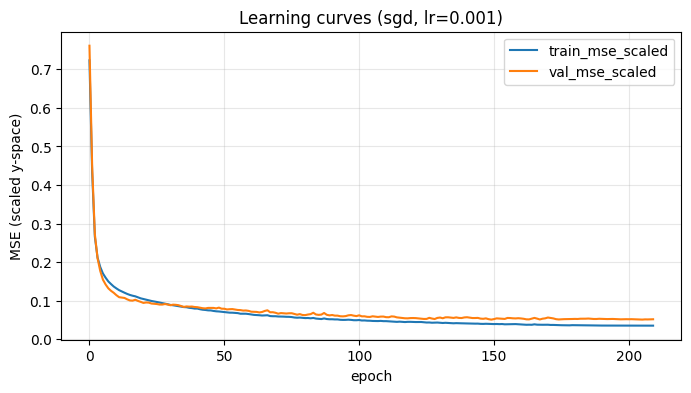

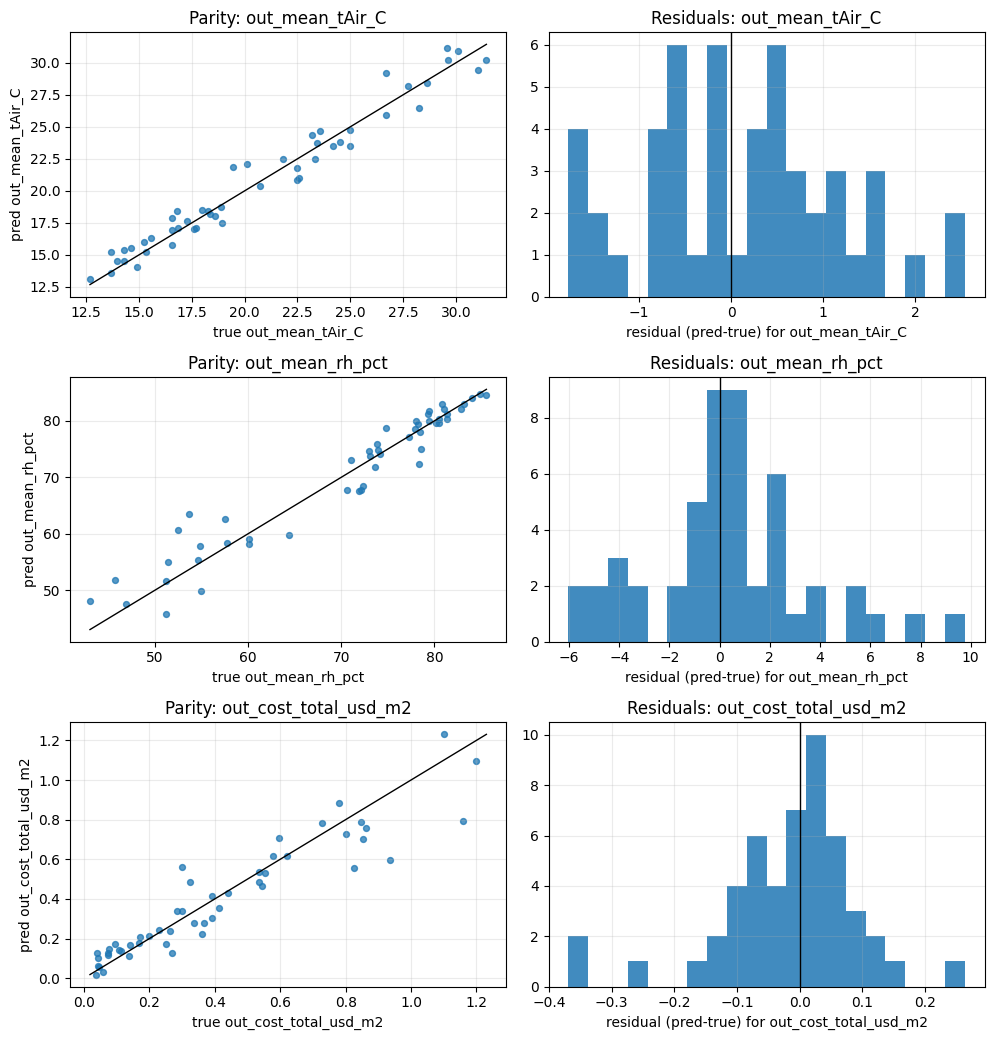

In [14]:
import matplotlib.pyplot as plt

# Learning curves (scaled MSE)
plt.figure(figsize=(8, 4))
plt.plot(train_mse_hist, label="train_mse_scaled")
plt.plot(val_mse_hist, label="val_mse_scaled")
plt.xlabel("epoch")
plt.ylabel("MSE (scaled y-space)")
plt.title(f"Learning curves ({OPTIMIZER_NAME}, lr={LEARNING_RATE})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Parity + residuals (original units, test set)
y_true = y_test_raw
y_pred = test_pred_report

n_t = len(TARGET_COLS)
fig, axes = plt.subplots(nrows=n_t, ncols=2, figsize=(10, 3.5 * n_t))
if n_t == 1:
    axes = np.array([axes])

for i, tgt in enumerate(TARGET_COLS):
    ax_parity = axes[i, 0]
    ax_resid = axes[i, 1]

    yt = y_true[:, i]
    yp = y_pred[:, i]
    resid = yp - yt

    # Parity
    ax_parity.scatter(yt, yp, s=18, alpha=0.75)
    lo = float(min(yt.min(), yp.min()))
    hi = float(max(yt.max(), yp.max()))
    ax_parity.plot([lo, hi], [lo, hi], color="black", linewidth=1)
    ax_parity.set_xlabel(f"true {tgt}")
    ax_parity.set_ylabel(f"pred {tgt}")
    ax_parity.set_title(f"Parity: {tgt}")
    ax_parity.grid(True, alpha=0.25)

    # Residuals
    ax_resid.hist(resid, bins=20, alpha=0.85)
    ax_resid.axvline(0.0, color="black", linewidth=1)
    ax_resid.set_xlabel(f"residual (pred-true) for {tgt}")
    ax_resid.set_title(f"Residuals: {tgt}")
    ax_resid.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

### Quick map (where to edit what)

| What you want | Where |
|---------------|-------|
| Which CSV columns are inputs | `RAW_INPUT_COLS` |
| Which outputs to predict | `TARGET_COLS` |
| Season encoding on/off | `USE_CYCLICAL_MONTH` |
| Hidden layer sizes | `HIDDEN_SIZES` |
| LR / epochs / batch / L2 | `LEARNING_RATE`, `N_EPOCHS`, `BATCH_SIZE`, `WEIGHT_DECAY` |
| Scaling inputs | `build_xy()` (`StandardScaler` swap) |
| Scaling targets | comment in `build_xy()` |
| Layers, dropout, activation | `SurrogateMLP` |
| Optimizer / loss | cell below CONFIG (`AdamW`, `MSELoss`) |
| Train loop extras | bottom of PyTorch cell |
| Save checkpoint | commented block at end of PyTorch cell |

## Save + load artifacts (model, scaler, metadata)

A predictor isn’t “real” until you can reload it and reproduce the same preprocessing + outputs.

This saves:
- `models/mlp_surrogate.pt` (PyTorch weights + metadata)
- `models/mlp_surrogate_scaler.joblib` (the fitted `scaler_X`)

In [ ]:
# ╔════════════════════════════════════════════════════════════════════════════╗
# ║  SAVE / LOAD — fill in paths to checkpoint + scaler pickle                ║
# ╚════════════════════════════════════════════════════════════════════════════╝

# CHANGE HERE:
# MODEL_PATH = Path(project_dir) / "models" / "mlp_surrogate.pt"
# torch.save({"state_dict": model.state_dict(), "feature_names": FEATURE_NAMES,
#             "target_cols": TARGET_COLS, "hidden": HIDDEN_SIZES}, MODEL_PATH)

from pathlib import Path

import joblib

MODELS_DIR = Path(project_dir) / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = MODELS_DIR / "mlp_surrogate.pt"
SCALER_PATH = MODELS_DIR / "mlp_surrogate_scaler.joblib"

# Save
joblib.dump(scaler_X, SCALER_PATH)

torch.save(
    {
        "state_dict": model.state_dict(),
        "feature_names": FEATURE_NAMES,
        "raw_input_cols": RAW_INPUT_COLS,
        "use_cyclical_month": USE_CYCLICAL_MONTH,
        "target_cols": TARGET_COLS,
        "hidden_sizes": tuple(HIDDEN_SIZES),
        "n_features": int(n_features),
        "n_targets": int(n_targets),
        "random_seed": int(RANDOM_SEED),
        "torch_seed": int(TORCH_SEED),
    },
    MODEL_PATH,
)

print(f"Saved model → {MODEL_PATH}")
print(f"Saved scaler → {SCALER_PATH}")


# Load (example)
loaded = torch.load(MODEL_PATH, map_location="cpu")
scaler_loaded = joblib.load(SCALER_PATH)

model_loaded = SurrogateMLP(
    n_in=loaded["n_features"],
    n_out=loaded["n_targets"],
    hidden=loaded["hidden_sizes"],
)
model_loaded.load_state_dict(loaded["state_dict"])
model_loaded.eval()

print("Reload ok. Feature names:", loaded["feature_names"])

## Inference helpers (turn new inputs into predictions)

These functions let you pass in new control inputs (and month) and get predicted `out_*` values back with column names.

In [ ]:
def predict_from_dataframe(
    inputs_df: pd.DataFrame,
    model_for_infer: nn.Module,
    scaler_for_infer: StandardScaler,
) -> pd.DataFrame:
    """inputs_df must include RAW_INPUT_COLS (e.g. in_* plus start_month)."""
    X_df = engineer_features(inputs_df)
    X_scaled = scaler_for_infer.transform(X_df)

    X_t = torch.tensor(X_scaled, dtype=torch.float32)
    with torch.no_grad():
        y_pred = model_for_infer(X_t).numpy()

    return pd.DataFrame(y_pred, columns=TARGET_COLS)


def predict_one(
    *,
    tSpDay: float,
    tSpNight: float,
    thetaLampMax: float,
    heatDeadZone: float,
    rhMax: float,
    start_month: int,
    model_for_infer: nn.Module = model_loaded,
    scaler_for_infer: StandardScaler = scaler_loaded,
) -> pd.Series:
    """Convenience wrapper for a single scenario."""
    row = {
        "in_tSpDay": float(tSpDay),
        "in_tSpNight": float(min(tSpNight, tSpDay)),
        "in_thetaLampMax": float(thetaLampMax),
        "in_heatDeadZone": float(heatDeadZone),
        "in_rhMax": float(rhMax),
        "start_month": int(start_month),
    }
    pred_df = predict_from_dataframe(pd.DataFrame([row]), model_for_infer, scaler_for_infer)
    return pred_df.iloc[0]


# Example call (CHANGE HERE)
example_pred = predict_one(
    tSpDay=19.0,
    tSpNight=17.0,
    thetaLampMax=10.0,
    heatDeadZone=5.0,
    rhMax=85.0,
    start_month=4,
)
example_pred

## Reproducible splits (save which rows are in train/val/test)

This makes your results comparable across runs and across different model types (NN vs XGBoost).

In [ ]:
SPLIT_PATH = MODELS_DIR / "mlp_surrogate_splits.json"

splits = {
    "random_seed": int(RANDOM_SEED),
    "train": {
        "row_index": train_df.index.tolist(),
        "sim_id": train_df["sim_id"].astype(int).tolist(),
    },
    "val": {
        "row_index": val_df.index.tolist(),
        "sim_id": val_df["sim_id"].astype(int).tolist(),
    },
    "test": {
        "row_index": test_df.index.tolist(),
        "sim_id": test_df["sim_id"].astype(int).tolist(),
    },
}

import json

with open(SPLIT_PATH, "w") as f:
    json.dump(splits, f, indent=2)

print(f"Saved splits → {SPLIT_PATH}")
print("Counts:", len(splits["train"]["sim_id"]), len(splits["val"]["sim_id"]), len(splits["test"]["sim_id"]))

## Sanity checks

- Show a few `y_true` vs `y_pred` rows from the test set
- Summarize absolute error per target

In [ ]:
# Predict on the (already-scaled) test arrays using the *trained* model
model.eval()
with torch.no_grad():
    test_pred_np = model(X_test_t).cpu().numpy()

true_df = pd.DataFrame(y_test, columns=TARGET_COLS).reset_index(drop=True)
pred_df = pd.DataFrame(test_pred_np, columns=[f"pred_{c}" for c in TARGET_COLS])

compare = pd.concat([true_df, pred_df], axis=1)
for c in TARGET_COLS:
    compare[f"abs_err_{c}"] = (compare[f"pred_{c}"] - compare[c]).abs()

# A few examples
compare.sample(n=min(8, len(compare)), random_state=RANDOM_SEED)

# Summary stats
err_cols = [f"abs_err_{c}" for c in TARGET_COLS]
compare[err_cols].describe()